In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import submission as sub
import helper
import random
import findM2
import visualize
import cv2 as cv2

if __name__ == '__main__':

    data = np.load('../data/some_corresp.npz')
    im1 = plt.imread('../data/im1.png')
    im2 = plt.imread('../data/im2.png')

    N = data['pts1'].shape[0]
    M = max(im1.shape[0], im1.shape[1])

    pts1 = data['pts1']
    pts2 = data['pts2']

    intrinsics = np.load('../data/intrinsics.npz')
    K1 = intrinsics['K1']
    K2 = intrinsics['K2']
    print('----------------  QUESTION 2.1  ---------------')

----------------  QUESTION 2.1  ---------------


display epipolar F

Given a correspondence pair in homogeneous image coordinates $x = [u, v, 1]^T$ (in image 1) and $x' = [u', v', 1]^T$ (in image 2), the fundamental matrix $F \in \mathbb{R}^{3\times 3}$ satisfies the epipolar constraint

$$
{x'}^T F x = 0.
$$

For a selected point $x$ in image 1, the corresponding epipolar line in image 2 is

$$
\ell' = F x = [a, b, c]^T,
$$

so every valid match $x'$ must lie on the line

$$
a u' + b v' + c = 0.
$$

Similarly, from a point $x'$ in image 2, the epipolar line in image 1 is

$$
\ell = F^T x'.
$$

`helper.displayEpipolarF(im1, im2, F)` visualizes this geometry by taking clicked points in one image, computing the corresponding epipolar line in the other image, and drawing that line. If $F$ is accurate, true matching points should lie close to their predicted epipolar lines (small algebraic/geometric error).

Optimization terminated successfully.
         Current function value: 0.000107
         Iterations: 8
         Function evaluations: 818
['F', 'M']
F from eight point algo:  [[ 9.78833286e-10 -1.32135929e-07  1.12585666e-03]
 [-5.73843315e-08  2.96800276e-09 -1.17611996e-05]
 [-1.08269003e-03  3.04846703e-05 -4.47032655e-03]]


g:\Old_Disk\Documents\Develpos\EpipolarGeometry\3D-Reconstruction-and-Epipolar-Geometry\python\helper.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  x, y = plt.ginput(1, mouse_stop=2)[0]


IndexError: list index out of range

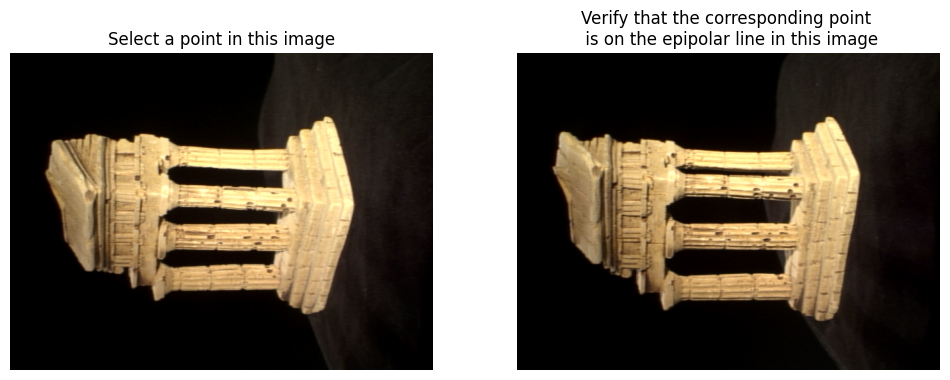

In [2]:
F = sub.eightpoint(pts1, pts2, M)
np.savez('../data/q2_1.npz', F=F, M=M)
print(np.load('../data/q2_1.npz').files)
print('F from eight point algo: ', F)
helper.displayEpipolarF(im1, im2, F)


## Q2.2 — Seven-Point Algorithm for the Fundamental Matrix

The **seven-point algorithm** estimates $F$ from exactly 7 point correspondences $\{(x_i, x'_i)\}_{i=1}^{7}$.

### Setup

Writing $F$ as a $9$-vector $\mathbf{f} = \text{vec}(F)$, each correspondence contributes one linear equation

$$
a_i^T \mathbf{f} = 0, \qquad a_i = \bigl[u_i u'_i,\; u_i v'_i,\; u_i,\; v_i u'_i,\; v_i v'_i,\; v_i,\; u'_i,\; v'_i,\; 1\bigr]^T.
$$

Stacking all 7 rows gives the $7\times 9$ system $A\mathbf{f} = 0$.

### Null Space

Because $A$ is $7\times 9$, its null space is (generically) **2-dimensional**. Let $F_1$ and $F_2$ be two basis vectors reshaped into $3\times 3$ matrices. Then every solution is

$$
F(\alpha) = \alpha F_1 + (1-\alpha) F_2.
$$

### Singularity Constraint

A valid fundamental matrix must satisfy $\det(F) = 0$. Substituting gives a **cubic polynomial in $\alpha$**:

$$
\det\!\bigl(\alpha F_1 + (1-\alpha) F_2\bigr) = 0,
$$

which yields **up to 3 real solutions** $\alpha_1, \alpha_2, \alpha_3$, and thus up to 3 candidate matrices $F_1^*, F_2^*, F_3^*$.

The code selects `F_list[:,:,0]` (the first solution) and saves it for validation with `helper.displayEpipolarF`.

In [ ]:
print('----------------  QUESTION 2.2  ---------------')

points_index = random.sample(range(0, pts1.shape[0]), 7)
points_index = [93, 61, 20, 72, 36, 87, 39]
print('selected 7 points: ', points_index)

sevenpoints_1 = []
sevenpoints_2 = []

for point in points_index:
    sevenpoints_1.append(pts1[point, :])
    sevenpoints_2.append(pts2[point, :])

sevenpoints_1 = np.asarray(sevenpoints_1)
sevenpoints_2 = np.asarray(sevenpoints_2)

F_list =   sub.sevenpoint(sevenpoints_1, sevenpoints_2, M)
F_sevenpoint = F_list[:,:,0]
# F3 gives the best value
np.savez('../data/q2_2.npz', F=F_sevenpoint, M=M, pts1=sevenpoints_1, pts2=sevenpoints_2)
print('F from seven point algo: ', F_sevenpoint)
print(np.load('../data/q2_2.npz').files)
helper.displayEpipolarF(im1, im2, F_sevenpoint)

## Q3.1 — Essential Matrix from the Fundamental Matrix

### Relation between $F$ and $E$

Given the calibration matrices $K_1, K_2 \in \mathbb{R}^{3\times3}$ of the two cameras, the **Essential matrix** $E$ encodes the same epipolar geometry as $F$ but in **normalised (camera) coordinates**:

$$
E = K_2^T \, F \, K_1.
$$

For a correspondence pair $\mathbf{x} = K_1^{-1} x$ and $\mathbf{x}' = K_2^{-1} x'$ in normalised coordinates:

$$
{\mathbf{x}'}^T E\, \mathbf{x} = 0.
$$

### Properties of $E$

A valid essential matrix has two equal non-zero singular values and one zero singular value. Concretely, if

$$
E = U \Sigma V^T, \qquad \Sigma = \operatorname{diag}(\sigma_1, \sigma_2, \sigma_3),\quad \sigma_1 \geq \sigma_2 \geq \sigma_3,
$$

then for $E$ to be essential we need $\sigma_1 = \sigma_2$ and $\sigma_3 = 0$. In practice the matrix computed from $K_2^T F K_1$ is projected onto the essential-matrix manifold by enforcing

$$
E \leftarrow U \operatorname{diag}(1, 1, 0) V^T.
$$

### What the code does

`sub.essentialMatrix(F, K1, K2)` applies the formula above: it computes $E = K_2^T F K_1$, then enforces the rank-2 / equal-singular-value constraint so the result lies on the essential-matrix manifold.

In [ ]:
print('----------------  QUESTION 3.1  ---------------')

intrinsics = np.load('../data/intrinsics.npz')
K1 = intrinsics['K1']
K2 = intrinsics['K2']
F = sub.eightpoint(pts1, pts2, M)
E = sub.essentialMatrix(F, K1, K2)
print('F from eight point algo: ', F)
print('Eseenetial Matrix from eight point algo: ', E)

Q3.2

In [4]:
data = np.load('../data/some_corresp.npz')
N = data['pts1'].shape[0]
M = 640
pts1 = data['pts1']
pts2 = data['pts2']
# EIGHT POINT ALGO
F = sub.eightpoint(pts1, pts2, M)
print('F: ', F)


Optimization terminated successfully.
         Current function value: 0.000107
         Iterations: 8
         Function evaluations: 818
F:  [[ 9.78833286e-10 -1.32135929e-07  1.12585666e-03]
 [-5.73843315e-08  2.96800276e-09 -1.17611996e-05]
 [-1.08269003e-03  3.04846703e-05 -4.47032655e-03]]


## Q3.3 — Camera Pose Recovery and Triangulation

### Step 1: Essential Matrix

From the fundamental matrix $F$ and calibration matrices $K_1$, $K_2$:

$$
E = K_2^T F K_1.
$$

### Step 2: Four Candidate Camera Matrices

Decompose $E$ via SVD:

$$
E = U \Sigma V^T.
$$

This yields **four** candidate second-camera projection matrices $M_2^{(k)}$, $k=1\ldots4$, assembled from $U$, $V$, and the skew-symmetric matrix

$$
W = \begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix},
$$

as the pairs $\{UWV^T \mid \mathbf{u}_3\}$, $\{UWV^T \mid -\mathbf{u}_3\}$, $\{UW^TV^T \mid \mathbf{u}_3\}$, $\{UW^TV^T \mid -\mathbf{u}_3\}$ where $\mathbf{u}_3$ is the third column of $U$.

The first camera is fixed as $M_1 = [I \mid \mathbf{0}]$ and the camera matrices are

$$
C_1 = K_1 M_1, \qquad C_2^{(k)} = K_2 M_2^{(k)}.
$$

### Step 3: Triangulation

For each candidate $C_2^{(k)}$, triangulate all $N$ correspondences by solving the linear system

$$
\begin{bmatrix} x_i (C_1[2,:]) - C_1[0,:] \\ y_i (C_1[2,:]) - C_1[1,:] \\ x'_i (C_2[2,:]) - C_2[0,:] \\ y'_i (C_2[2,:]) - C_2[1,:] \end{bmatrix} \mathbf{P}_i = 0,
$$

via SVD to recover 3-D point $\mathbf{P}_i \in \mathbb{R}^3$.

The **reprojection error** for a solution is

$$
\text{err} = \frac{1}{N}\sum_{i=1}^{N} \left( \left\| x_i - \hat{x}_i \right\|^2 + \left\| x'_i - \hat{x}'_i \right\|^2 \right).
$$

### Step 4: Cheirality Check

The correct $M_2$ is the one for which **all** reconstructed points have positive depth in both cameras (positive $Z$ coordinate):

$$
Z(\mathbf{P}_i) > 0 \quad \forall\, i.
$$

`bestM2` iterates over the four candidates, applies the cheirality check, and returns the best $M_2$, $C_2$, 3-D point cloud $P$, and reprojection error.

In [7]:
 # GET INTRINSICS
from findM2 import bestM2
intrinsics = np.load('../data/intrinsics.npz')
K1 = intrinsics['K1']
K2 = intrinsics['K2']
P_best, C2_best, M2_best, err_best = bestM2(pts1, pts2, F, K1, K2)
np.savez('../data/q3_3.npz', M2=M2_best, C2=C2_best, P=P_best )
data = np.load('../data/q3_3.npz')
print(data.files)


['M2', 'C2', 'P']


## Q4.1 — Epipolar Correspondence via Patch Matching

### Goal

Given a query pixel $(x_1, y_1)$ in image 1, find its best match $(x_2, y_2)$ in image 2 by searching **only along the corresponding epipolar line**, rather than exhaustively over the whole image.

### Step 1: Compute the Epipolar Line

The query point in homogeneous coordinates is $\mathbf{v} = [x_1, y_1, 1]^T$. Its epipolar line in image 2 is

$$
\boldsymbol{\ell} = F \mathbf{v} = [a, b, c]^T.
$$

Normalising to unit length:

$$
\boldsymbol{\ell} \leftarrow \frac{\boldsymbol{\ell}}{\sqrt{a^2 + b^2}},
$$

the line equation in image 2 is $a x' + b y' + c = 0$.

### Step 2: Sample Candidate Points

The line is intersected with the image boundary to obtain endpoints $(x_s, y_s)$ and $(x_e, y_e)$. The candidate set

$$
\{(x_2^{(i)}, y_2^{(i)})\}_{i=1}^{N}
$$

is obtained by uniformly sampling $N$ integer pixel positions along the segment.

### Step 3: Gaussian-Weighted Patch Matching

For each candidate pixel, a $k \times k$ patch is extracted from image 2 (here $k = 51$). The similarity to the reference patch around $(x_1, y_1)$ in image 1 is measured with a **Gaussian-weighted SSD**:

$$
e^{(i)} = \left\| G_\sigma \odot \bigl(P_1 - P_2^{(i)}\bigr) \right\|_F,
$$

where $G_\sigma$ is a $k\times k$ Gaussian kernel with $\sigma = 31$, and $\odot$ denotes element-wise multiplication applied independently to each colour channel.

### Step 4: Best Match

The correspondence is the candidate with minimum error:

$$
(x_2^*, y_2^*) = \arg\min_{i}\; e^{(i)}.
$$

### What the code does

`helper.epipolarMatchGUI` lets the user click points in image 1 and calls `sub.epipolarCorrespondence(im1, im2, F, x1, y1)` for each click, which implements the steps above and returns the best $(x_2, y_2)$. The manually collected correspondences `pts1_GUI` / `pts2_GUI` are saved to `q4_1.npz` for use in downstream steps.

In [8]:
x1 = pts1[:,0]
y1 = pts1[:,1]
# FIND EPIPOLAR PTS2 CORRESPONDANCES
pts1_new = []
pts2_new = []
F = sub.eightpoint(pts1, pts2, M)
# helper.epipolarMatchGUI(im1, im2, F)
pts1_GUI = np.asarray( [
[126.67419354838708, 210.11367741935487],
[70.65698924731183, 128.35883870967746],
[480.94516129032263, 95.05131182795697],
[494.57096774193553, 152.58249462365586],
[515.7666666666668, 229.79539784946235],
[427.95591397849466, 132.9007741935484],
[329.54731182795706, 231.309376344086],
[229.62473118279567, 219.19754838709684],
[447.63763440860225, 387.24916129032266],
[169.06559139784943, 129.8728172043011],
[373.45268817204305, 223.73948387096777]
] )
pts2_GUI = np.asarray( [
[125, 174],
[70, 116],
[471, 95],
[488, 132],
[513, 188],
[422, 137],
[329, 211],
[228, 201],
[457, 397],
[168, 133],
[372, 205]
] )
np.savez('../data/q4_1.npz', F=F, pts1=pts1_GUI, pts2=pts2_GUI)
print(np.load('../data/q4_1.npz').files)
print(np.load('../data/q4_1.npz')['pts1'])
print(np.load('../data/q4_1.npz')['pts2'])


Optimization terminated successfully.
         Current function value: 0.000107
         Iterations: 8
         Function evaluations: 818
['F', 'pts1', 'pts2']
[[126.67419355 210.11367742]
 [ 70.65698925 128.35883871]
 [480.94516129  95.05131183]
 [494.57096774 152.58249462]
 [515.76666667 229.79539785]
 [427.95591398 132.90077419]
 [329.54731183 231.30937634]
 [229.62473118 219.19754839]
 [447.63763441 387.24916129]
 [169.0655914  129.8728172 ]
 [373.45268817 223.73948387]]
[[125 174]
 [ 70 116]
 [471  95]
 [488 132]
 [513 188]
 [422 137]
 [329 211]
 [228 201]
 [457 397]
 [168 133]
 [372 205]]


## Q4.2 — Dense 3-D Reconstruction from Temple Coordinates

This cell combines **epipolar correspondence** (Q4.1) with **triangulation and pose recovery** (Q3.3) to produce a dense 3-D point cloud of the temple scene.

### Pipeline Overview

#### Step 1: Camera 1 setup

Camera 1 is placed at the world origin with the canonical projection matrix:

$$
M_1 = \begin{bmatrix} I_{3\times3} & \mathbf{0} \end{bmatrix}, \qquad C_1 = K_1 M_1.
$$

#### Step 2: Epipolar correspondence for each query point

For every query pixel $(x_1^{(i)}, y_1^{(i)})$ from `templeCoords.npz`, the matching pixel $(x_2^{(i)}, y_2^{(i)})$ in image 2 is found by Gaussian-weighted patch search along the epipolar line (see Q4.1):

$$
\boldsymbol{\ell}^{(i)} = F\,[x_1^{(i)},\, y_1^{(i)},\, 1]^T.
$$

Only points for which a valid match is found (non-`None` return) are kept, giving filtered sets $\mathbf{pts}_1^{\text{new}}$ and $\mathbf{pts}_2^{\text{new}}$.

#### Step 3: Camera 2 pose via cheirality

`bestM2` (Q3.3) decomposes the essential matrix

$$
E = K_2^T F K_1
$$

into four candidate $[R \mid \mathbf{t}]$ pairs and selects $M_2^*$ as the one satisfying the **cheirality constraint** — all triangulated points have positive depth:

$$
Z(\mathbf{P}_i) > 0, \quad \forall\, i.
$$

The calibrated camera matrix is $C_2 = K_2 M_2^*$.

#### Step 4: Linear triangulation

For each accepted correspondence, the 3-D point $\mathbf{P}_i \in \mathbb{R}^3$ is recovered by solving the linear system

$$
A_i \tilde{\mathbf{P}}_i = 0, \qquad
A_i = \begin{bmatrix}
x_1^{(i)} C_1[2,:] - C_1[0,:] \\
y_1^{(i)} C_1[2,:] - C_1[1,:] \\
x_2^{(i)} C_2[2,:] - C_2[0,:] \\
y_2^{(i)} C_2[2,:] - C_2[1,:]
\end{bmatrix}
$$

via SVD (take the right singular vector corresponding to the smallest singular value, then dehomogenise).

#### Step 5: 3-D visualisation

The resulting point cloud $\{P_i\}$ is displayed with `points_3d_visualize`, and the camera matrices $M_1$, $M_2^*$, $C_1$, $C_2$ are saved to `q4_2.npz` for further use.

In [9]:
from visualize import points_3d_visualize
from findM2 import bestM2
im1 = plt.imread('../data/im1.png')
im2 = plt.imread('../data/im2.png')
# LOAD SAMPLE PTS1
data = np.load('../data/templeCoords.npz')
x1 = data['x1'].astype(int).flatten()
y1 = data['y1'].astype(int).flatten()
# LOAD F
q2_1 = np.load('../data/q2_1.npz')
F = q2_1['F']
# LOAD INTRINSICS
intrinsics = np.load('../data/intrinsics.npz')
K1 = intrinsics['K1']
K2 = intrinsics['K2']
M1 = np.array([ [ 1,0,0,0 ],
                [ 0,1,0,0 ],
                [ 0,0,1,0 ]  ])
C1 = K1.dot(M1)
# FIND EPIPOLAR PTS2 CORRESPONDANCES
pts1_new = []
pts2_new = []
for i in range(x1.shape[0]):
    x2, y2 = sub.epipolarCorrespondence(im1, im2, F, x1[i], y1[i])
    if x2 is not None:
        pts1_new.append([ x1[i], y1[i] ])
        pts2_new.append([ x2, y2 ])
pts1_new = np.asarray(pts1_new)
pts2_new = np.asarray(pts2_new)
# print('pts1_new shape: ', pts1_new.shape)
# print('pts2_new shape: ', pts2_new.shape)
# FIND 3D POINTS USING TRIANGULATION
P_best, C2_best, M2_best, err_best = findM2.bestM2(pts1_new, pts2_new, F, K1, K2)
np.savez('../data/q4_2.npz', F=F, M1=M1, M2=M2_best, C1=C1 , C2=C2_best )
print(np.load('../data/q4_2.npz').files)
## 3D PLOT RECONSTRUCTION
points_3d_visualize(P_best)

['F', 'M1', 'M2', 'C1', 'C2']


TypeError: FigureBase.gca() got an unexpected keyword argument 'projection'

<Figure size 640x480 with 0 Axes>

## Q5.1 — Robust Fundamental Matrix Estimation with RANSAC

This section compares a direct eight-point estimate with a robust RANSAC-based estimate on noisy correspondences.

### Problem Setup

Given noisy matches

$$
\{(x_i, x'_i)\}_{i=1}^{N}, \quad x_i = [u_i, v_i, 1]^T,\; x'_i = [u'_i, v'_i, 1]^T,
$$

a fundamental matrix must satisfy the epipolar constraint

$$
{x'_i}^T F x_i = 0.
$$

With noise/outliers, enforcing this on all points directly (eight-point on all matches) is sensitive to bad correspondences.

### RANSAC Model in This Code

#### Step 1: Minimal sampling

At each epoch, 7 correspondences are sampled (minimal set for seven-point):

$$
\mathcal{S}_t \subset \{1,\dots,N\}, \quad |\mathcal{S}_t| = 7.
$$

#### Step 2: Candidate models

From each 7-point set, `sevenpoint` returns up to 3 candidates

$$
\{F_t^{(j)}\}_{j=1}^{m_t}, \quad m_t \le 3.
$$

#### Step 3: Inlier test

For every candidate and every correspondence, the code uses the algebraic residual

$$
r_i^{(j)} = \left|{x'_i}^T F_t^{(j)} x_i\right|,
$$

and marks point $i$ as an inlier if

$$
r_i^{(j)} < \tau, \qquad \tau = 10^{-3}.
$$

So the inlier set is

$$
\mathcal{I}_t^{(j)} = \{i : |{x'_i}^T F_t^{(j)} x_i| < \tau\}.
$$

#### Step 4: Best consensus

Across all epochs (here 1000) and all candidate matrices, choose the model with maximum consensus size:

$$
(j^*, t^*) = \arg\max_{t,j} |\mathcal{I}_t^{(j)}|.
$$

### Final Re-estimation

After identifying inliers, the implementation recomputes the final matrix using **eight-point on all inliers**:

$$
F_{\text{RANSAC}} = \texttt{eightpoint}\bigl(\{(x_i, x'_i) : i \in \mathcal{I}^*\}\bigr).
$$

This final refinement usually improves geometric consistency compared with using a single minimal 7-point hypothesis.

### What the Q5.1 code compares

The code reports reprojection error for:

1. `F_eight`: eight-point using all noisy correspondences.
2. `F_ransac`: RANSAC inlier selection + eight-point re-estimation on inliers.

Lower error after RANSAC indicates successful rejection of outliers and a more reliable epipolar geometry estimate.

In [10]:
 # COMPARISON OF EIGHT POINT AND RANSAC
data = np.load('../data/some_corresp_noisy.npz')
pts1 = data['pts1'].astype(int)
pts2 = data['pts2'].astype(int)


# EIGHT POINT
F_eight = sub.eightpoint(pts1, pts2, M)
P_init, C2_init, M2_init, err = findM2.bestM2(pts1, pts2, F_eight, K1, K2)
print('reprojection error for eight point algo: ', err)
# helper.displayEpipolarF(im1, im2, F_eight)

# RANSAC
F_ransac, inliers_best = sub.ransacF(pts1, pts2, M)
pts1_inliers= pts1[np.where(inliers_best)]
pts2_inliers= pts2[np.where(inliers_best)]
P_init, C2_init, M2_init, err = findM2.bestM2(pts1_inliers, pts2_inliers, F_ransac, K1, K2)
print('reprojection error after ransac: ', err)
# helper.displayEpipolarF(im1, im2, F_ransac)

Optimization terminated successfully.
         Current function value: 3.423417
         Iterations: 11
         Function evaluations: 1449
reprojection error for eight point algo:  inf
epoch:  999 max_inliers:  103
Optimization terminated successfully.
         Current function value: 0.000071
         Iterations: 7
         Function evaluations: 726
reprojection error after ransac:  723.2475698144746


## Q5.2 — Rodrigues / Inverse Rodrigues and Pose Parameterization

This section validates the conversion between rotation-vector and rotation-matrix forms, then uses that parameterization for camera-pose refinement.

### 1) Rodrigues Formula: $\mathbf{r} \rightarrow R$

Let $\mathbf{r} \in \mathbb{R}^3$ be the axis-angle vector:

$$
\theta = \|\mathbf{r}\|_2, \qquad \mathbf{u} = \frac{\mathbf{r}}{\theta}.
$$

Define the skew-symmetric matrix

$$
[\mathbf{u}]_\times =
\begin{bmatrix}
0 & -u_3 & u_2 \\
u_3 & 0 & -u_1 \\
-u_2 & u_1 & 0
\end{bmatrix}.
$$

Rodrigues gives

$$
R = I\cos\theta + (1-\cos\theta)\,\mathbf{u}\mathbf{u}^T + [\mathbf{u}]_\times\sin\theta.
$$

This is exactly what `sub.rodrigues(r)` computes.

### 2) Inverse Rodrigues: $R \rightarrow \mathbf{r}$

From a rotation matrix $R$, define

$$
A = \frac{R - R^T}{2}, \quad
\boldsymbol{\rho} = [A_{32}, A_{13}, A_{21}]^T,
$$

$$
s = \|\boldsymbol{\rho}\|_2, \qquad
c = \frac{\operatorname{trace}(R)-1}{2}, \qquad
\theta = \operatorname{atan2}(s,c).
$$

For the generic case ($s \neq 0$),

$$
\mathbf{u} = \frac{\boldsymbol{\rho}}{s}, \qquad
\mathbf{r} = \theta\mathbf{u}.
$$

Special cases handled in the code:

1. $s=0, c=1 \Rightarrow \mathbf{r}=\mathbf{0}$ (identity rotation).
2. $s=0, c=-1 \Rightarrow \theta=\pi$ branch with sign disambiguation.

This is what `sub.invRodrigues(R)` implements.

### 3) Why this matters for optimization

Instead of optimizing 9 unconstrained entries of $R$, we optimize only 3 parameters $\mathbf{r}$. Then

$$
M_2 = [R(\mathbf{r}) \mid \mathbf{t}], \qquad C_2 = K_2 M_2.
$$

Together with 3-D points $P_i$, the residual vector stacks reprojection differences in both images:

$$
\mathbf{e}(\mathbf{x}) =
\begin{bmatrix}
\mathbf{p}_1 - \hat{\mathbf{p}}_1(\mathbf{x}) \\
\mathbf{p}_2 - \hat{\mathbf{p}}_2(\mathbf{x})
\end{bmatrix},
$$

and bundle adjustment minimizes

$$
\min_{\mathbf{x}} \; \|\mathbf{e}(\mathbf{x})\|_2^2,
$$

where $\mathbf{x}$ concatenates all 3-D points, $\mathbf{r}$, and $\mathbf{t}$.

So this cell first checks Rodrigues conversions (against OpenCV) and then uses them as the rotation parameterization for bundle-adjustment refinement.

In [13]:
from submission import rodrigues, invRodrigues
from visualize import points_3d_visualize
from findM2 import bestM2

r_test = np.asarray([1,1,1]).astype(float)
R = np.zeros( (3,3) )
cv2.Rodrigues(r_test, R, None)
print(R)
cv2.Rodrigues(R, r_test, None)
print(r_test)
R_init = sub.rodrigues(r_test)
print(R_init)
r = sub.invRodrigues(R_init)
print(r)
M1 = np.array([ [ 1,0,0,0 ],
                [ 0,1,0,0 ],
                [ 0,0,1,0 ]  ])
data = np.load('../data/some_corresp_noisy.npz')
pts1 = data['pts1'].astype(int)
pts2 = data['pts2'].astype(int)
M = 640
# RANSAC
F_ransac, inliers_best = sub.ransacF(pts1, pts2, M)
pts1_inliers= pts1[np.where(inliers_best)]
pts2_inliers= pts2[np.where(inliers_best)]
P_init, C2_init, M2_init, err = findM2.bestM2(pts1_inliers, pts2_inliers, F_ransac, K1, K2)
print('error before optimization: ', err)
# VISUALIZE INITIAL 3D POINTS
visualize.points_3d_visualize(P_init)
M2, P = sub.bundleAdjustment(K1, M1, pts1_inliers, K2, M2_init, pts2_inliers, P_init)
# CALCULATING REPROJECTION ERROR
P_temp, err_opt = sub.triangulate(K1.dot(M1), pts1_inliers, K2.dot(M2), pts2_inliers)
print('error after optimization: ', err_opt)
# VISUALIZE OPTIMIZED 3D POINTS
visualize.points_3d_visualize(P)

[[ 0.22629564 -0.18300792  0.95671228]
 [ 0.95671228  0.22629564 -0.18300792]
 [-0.18300792  0.95671228  0.22629564]]
[1. 1. 1.]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (3, 3) + inhomogeneous part.